# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute  import SimpleImputer

# Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/zeeshier/student-admission-records/student_admission_record_dirty.csv")

# Data Exploration Function

In [3]:
df.head(5)        # preview of first 5 rows

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
1,Waqar,21.0,Female,99.0,60.73,Karachi,NaN
2,Bushra,17.0,Male,89.0,NaN,Islamabad,Accepted
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
4,Bilal,20.0,Male,65.0,61.13,Lahore,NaN


In [4]:
 df.tail(5)        # preview of last 5 rows

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
152,Ali,19.0,Female,85.0,78.09,Quetta,Accepted
153,Bilal,17.0,Female,81.0,84.40,Islamabad,Rejected
154,Fatima,21.0,Female,98.0,50.86,Multan,Accepted
155,Shoaib,-1.0,Male,91.0,80.12,Quetta,Accepted
156,Maaz,17.0,Male,88.0,86.85,Lahore,Accepted


In [5]:
df.sample(5)

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
122,Tuba,17.0,Female,75.0,78.43,Peshawar,Accepted
104,Sara,22.0,NaN,95.0,60.33,Islamabad,Rejected
101,Shehroz,24.0,Male,72.0,90.05,Karachi,Accepted
79,Muneera,19.0,Female,81.0,67.75,Karachi,Rejected
134,Shahzad,24.0,Female,74.0,74.13,Multan,Rejected


In [6]:
df.shape

(157, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    147 non-null    object 
 1   Age                     147 non-null    float64
 2   Gender                  147 non-null    object 
 3   Admission Test Score    146 non-null    float64
 4   High School Percentage  146 non-null    float64
 5   City                    147 non-null    object 
 6   Admission Status        147 non-null    object 
dtypes: float64(3), object(4)
memory usage: 8.7+ KB


In [8]:
df.isnull().sum()      #count of null values of columns

Name                      10
Age                       10
Gender                    10
Admission Test Score      11
High School Percentage    11
City                      10
Admission Status          10
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(6)

In [10]:
df[df.duplicated(keep=False)].sort_values(by='Name')   #checking the inter-duplicated rows

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
13,Ahmed,21.0,Male,62.0,79.03,Karachi,Accepted
52,Ahmed,21.0,Male,62.0,79.03,Karachi,Accepted
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
88,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
36,Ayesha,24.0,Male,94.0,98.43,Multan,Rejected
120,Ayesha,24.0,Male,94.0,98.43,Multan,Rejected
61,Hamza,22.0,Male,99.0,86.58,Multan,Accepted
110,Hamza,22.0,Male,99.0,86.58,Multan,Accepted
9,Kamran,18.0,Male,53.0,98.98,Multan,Rejected
22,Kamran,18.0,Male,53.0,98.98,Multan,Rejected


In [11]:
df.drop_duplicates(inplace = True)    #removing the duplicates value

In [12]:
df.duplicated().sum()      #recheck that duplicate rows deleted or not

np.int64(0)

In [13]:
df.nunique()

Name                       64
Age                         9
Gender                      2
Admission Test Score       49
High School Percentage    129
City                        7
Admission Status            2
dtype: int64

In [14]:
df.describe()

,Age,Admission Test Score,High School Percentage
count,141.000000,140.000000,140.000000
mean,19.673759,77.857143,75.165929
std,4.603565,16.770380,17.467658
min,-1.000000,-5.000000,-10.000000
25%,18.000000,69.750000,63.535000
50%,20.000000,79.000000,76.195000
75%,22.000000,89.000000,88.217500
max,24.000000,150.000000,110.500000


In [15]:
df.corr(numeric_only = True)

,Age,Admission Test Score,High School Percentage
Age,1.000000,-0.010964,0.169317
Admission Test Score,-0.010964,1.000000,-0.125343
High School Percentage,0.169317,-0.125343,1.000000


# Data Visualization - Data Exploratory Analysis

<function matplotlib.pyplot.show(close=None, block=None)>

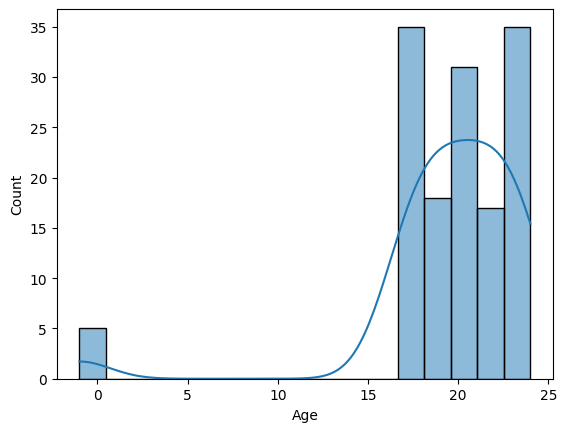

In [16]:
# Age Distribution 

sns.histplot(
    data = df,
    x = 'Age',
    kde = True
)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

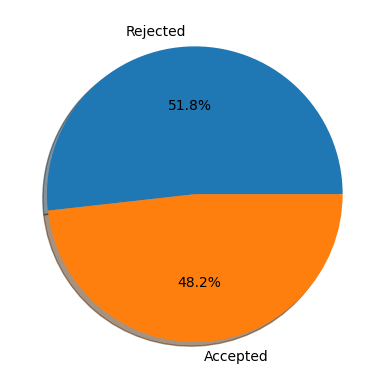

In [17]:
# Admission_Status Distribution

new_admission_status = df["Admission Status"].value_counts()
plt.pie(
    new_admission_status,
    labels = new_admission_status.index,
    autopct  = '%1.1f%%',
    shadow = True
)
plt.show

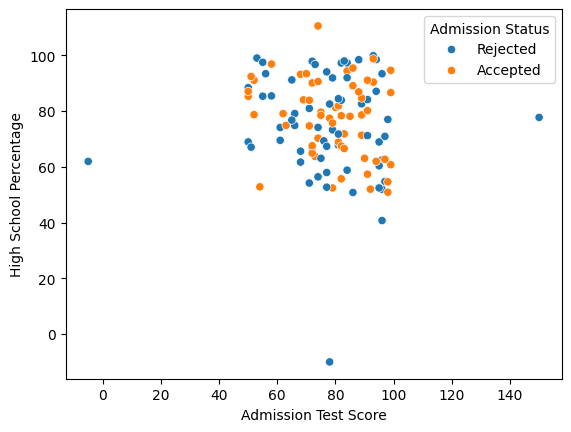

In [18]:
# Scatter plot: Admission Test Score vs High School Percentage by Admission Status

sns.scatterplot(
    data=df,
    x='Admission Test Score',
    y='High School Percentage',
    hue='Admission Status'
)

plt.show()

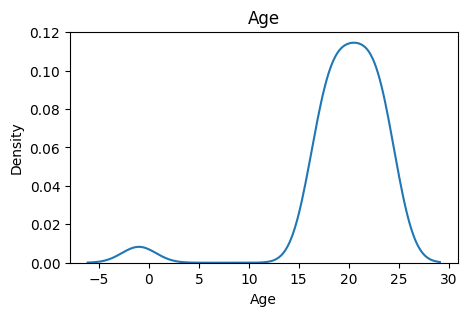

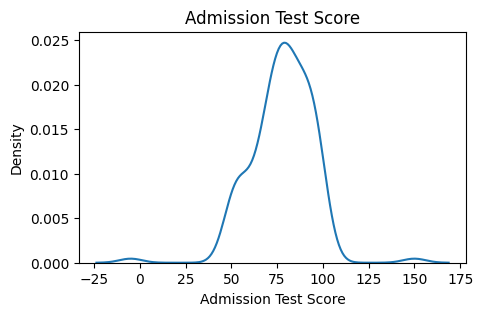

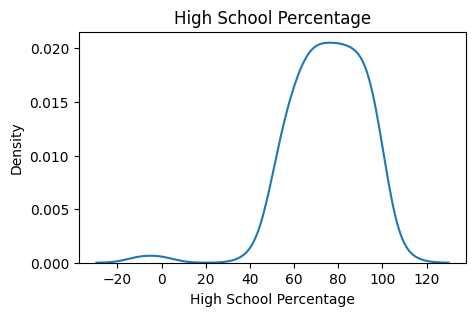

In [19]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(5, 3))
    sns.kdeplot(data=df, x=col)
    plt.title(col)
    plt.show()

<Axes: xlabel='City', ylabel='count'>

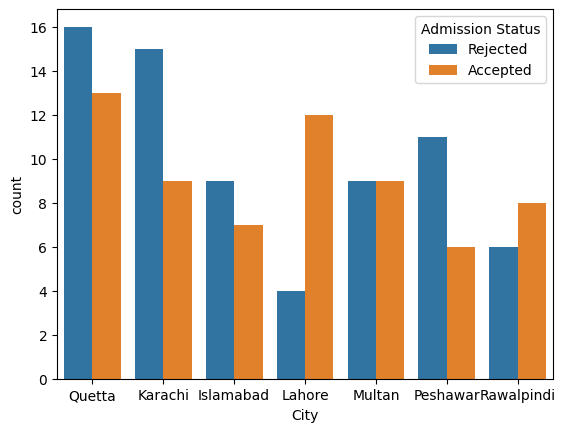

In [20]:
sns.countplot(
    data = df,
    x = 'City',
    hue = 'Admission Status'
)

<function matplotlib.pyplot.show(close=None, block=None)>

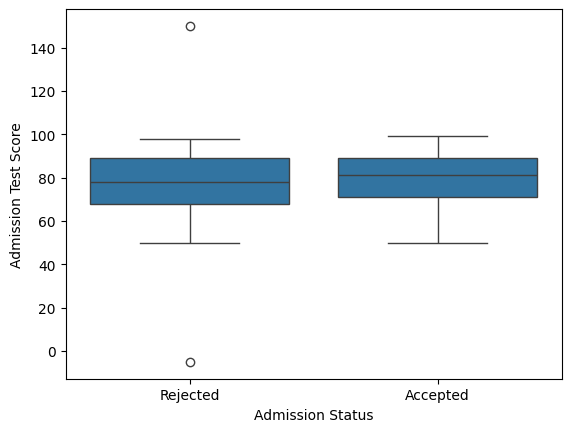

In [21]:
sns.boxplot(
    data = df,
    x = 'Admission Status',
    y = 'Admission Test Score'
)
plt.show

# Train Test split

In [22]:
# Starter column
df.drop(['Name'],axis=1,inplace = True)

In [23]:
# train column

X = df.drop(['Admission Status'],axis = 1)
X

,Age,Gender,Admission Test Score,High School Percentage,City
0,24.0,Female,50.0,68.90,Quetta
1,21.0,Female,99.0,60.73,Karachi
2,17.0,Male,89.0,NaN,Islamabad
3,17.0,Male,55.0,85.29,Karachi
4,20.0,Male,65.0,61.13,Lahore
...,...,...,...,...,...
152,19.0,Female,85.0,78.09,Quetta
153,17.0,Female,81.0,84.40,Islamabad
154,21.0,Female,98.0,50.86,Multan
155,-1.0,Male,91.0,80.12,Quetta


In [24]:
y = df['Admission Status']
y

0      Rejected
1           NaN
2      Accepted
3      Rejected
4           NaN
         ...   
152    Accepted
153    Rejected
154    Accepted
155    Accepted
156    Accepted
Name: Admission Status, Length: 151, dtype: object

In [25]:
#train test split code

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [26]:
X_train

,Age,Gender,Admission Test Score,High School Percentage,City
15,19.0,Male,84.0,97.19,Peshawar
131,17.0,Male,78.0,82.49,Quetta
11,18.0,Male,89.0,NaN,Lahore
133,20.0,Male,71.0,80.91,Lahore
53,23.0,NaN,98.0,76.97,NaN
...,...,...,...,...,...
73,18.0,NaN,80.0,81.30,Quetta
109,18.0,Female,72.0,67.51,NaN
14,22.0,Male,86.0,50.77,Islamabad
95,18.0,NaN,84.0,91.92,Quetta


In [27]:
X_test.shape

(31, 5)

In [28]:
y_train

15     Rejected
131    Rejected
11     Accepted
133    Rejected
53     Rejected
         ...   
73     Accepted
109    Accepted
14     Rejected
95     Rejected
105    Rejected
Name: Admission Status, Length: 120, dtype: object

In [29]:
y_test.shape

(31,)

# Missing Values Handling

In [30]:
# imputing numerical values



num_cols = ['Age', 'Admission Test Score','High School Percentage' ]

imputer = SimpleImputer(missing_values = np.nan,strategy='mean')

for col in num_cols:
    
    imputer.fit(X_train[[col]])
    
    X_train[col] = imputer.transform(X_train[[col]]).ravel()
    X_test[col] = imputer.transform(X_test[[col]]).ravel()

In [31]:
X_train.isnull().sum()

Age                       0
Gender                    9
Admission Test Score      0
High School Percentage    0
City                      6
dtype: int64

In [32]:
# Categorical missing value imputation - Multiple columns (Most Frequent)

cat_cols = ['Gender', 'City']

imputer = SimpleImputer(missing_values =np.nan, strategy='most_frequent')

for col in cat_cols:
    imputer.fit(X_train[[col]])
    X_train[col] = imputer.transform(X_train[[col]]).ravel()
    X_test[col] = imputer.transform(X_test[[col]]).ravel()

In [33]:
X_train.isnull().sum()

Age                       0
Gender                    0
Admission Test Score      0
High School Percentage    0
City                      0
dtype: int64

In [34]:
X_train

,Age,Gender,Admission Test Score,High School Percentage,City
15,19.0,Male,84.0,97.190000,Peshawar
131,17.0,Male,78.0,82.490000,Quetta
11,18.0,Male,89.0,74.494865,Lahore
133,20.0,Male,71.0,80.910000,Lahore
53,23.0,Female,98.0,76.970000,Karachi
...,...,...,...,...,...
73,18.0,Female,80.0,81.300000,Quetta
109,18.0,Female,72.0,67.510000,Karachi
14,22.0,Male,86.0,50.770000,Islamabad
95,18.0,Female,84.0,91.920000,Quetta


In [35]:
X_test

,Age,Gender,Admission Test Score,High School Percentage,City
78,20.000000,Female,91.000000,91.030000,Karachi
18,19.000000,Female,74.000000,70.260000,Lahore
84,19.616071,Female,99.000000,94.590000,Islamabad
83,20.000000,Male,96.000000,51.950000,Peshawar
149,21.000000,Female,86.000000,95.380000,Quetta
32,24.000000,Female,65.000000,91.140000,Multan
80,18.000000,Female,72.000000,67.510000,Quetta
66,24.000000,Female,79.000000,75.670000,Karachi
57,23.000000,Female,79.000000,52.390000,Karachi
87,19.616071,Female,81.000000,81.820000,Rawalpindi
